In [2]:
# Import libraries for advanced analytics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load cleaned datasets

delivery_analysis_clean = pd.read_csv("../outputs/delivery_analysis_clean.csv")
complaints_analysis_clean = pd.read_csv("../outputs/complaints_analysis_clean.csv")
incidents_analysis_clean = pd.read_csv("../outputs/incidents_analysis_clean.csv")

deliveries_clean = pd.read_csv("../outputs/deliveries_clean.csv")
vehicles_clean = pd.read_csv("../outputs/vehicles_clean.csv")
drivers_clean = pd.read_csv("../outputs/drivers_clean.csv")
complaints_clean = pd.read_csv("../outputs/complaints_clean.csv")
app_events_clean = pd.read_csv("../outputs/app_events_clean.csv")

DELAY ROOT-CAUSE ANALYSIS

In [4]:
# Calculate delay rate by service type

delay_by_service = (
    delivery_analysis_clean
    .groupby("service_type")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

print(delay_by_service)

service_type
business     0.543860
passenger    0.527426
parcel       0.524038
medical      0.468750
retail       0.443396
Name: is_delayed, dtype: float64


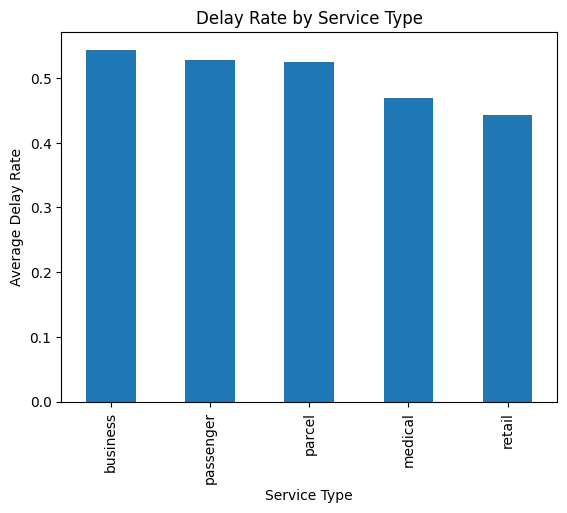

In [5]:
# Visualise delay rate by service type

delay_by_service.plot(kind="bar")

plt.title("Delay Rate by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Average Delay Rate")

plt.show()

In [6]:
# Analyse average delivery duration by hub

hub_duration = (
    delivery_analysis_clean
    .groupby("hub_name")["delivery_duration_minutes"]
    .mean()
    .sort_values(ascending=False)
)

print(hub_duration)

hub_name
Central Core      693.197992
West Gate         666.158091
North Exchange    641.098088
Midtown Relay     633.629429
Riverside Hub     632.153292
Airport Hub       595.045405
South Link        568.736887
East Dock         506.273564
Name: delivery_duration_minutes, dtype: float64


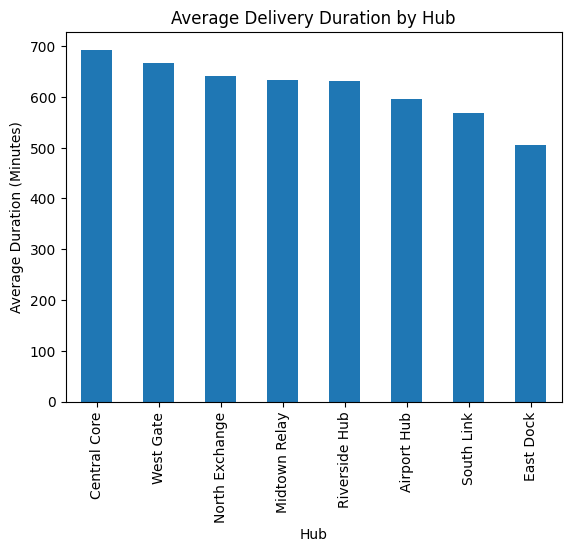

In [7]:
# Visualise average delivery duration by hub

hub_duration.plot(kind="bar")

plt.title("Average Delivery Duration by Hub")
plt.xlabel("Hub")
plt.ylabel("Average Duration (Minutes)")

plt.show()

In [8]:
# Analyse delay rate by pickup zone

zone_delay_rate = (
    delivery_analysis_clean
    .groupby("pickup_zone")["is_delayed"]
    .mean()
    .sort_values(ascending=False)
)

print(zone_delay_rate)

pickup_zone
ctr          0.661017
airport      0.533333
north        0.523810
east         0.520833
riverside    0.509091
central      0.505051
west         0.460000
south        0.379032
Name: is_delayed, dtype: float64


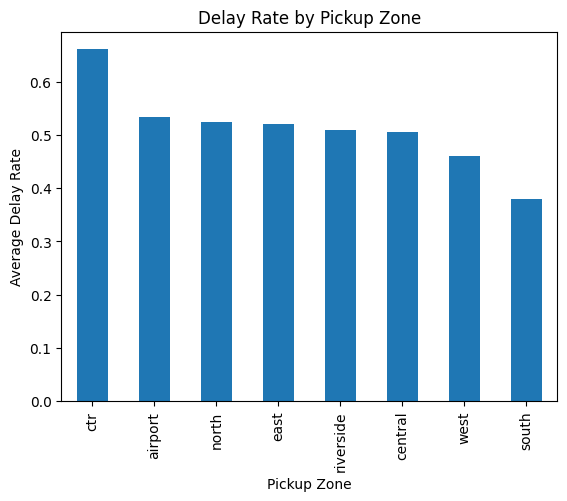

In [9]:
# Visualise delay rate by pickup zone

zone_delay_rate.plot(kind="bar")

plt.title("Delay Rate by Pickup Zone")
plt.xlabel("Pickup Zone")
plt.ylabel("Average Delay Rate")

plt.show()

CUSTOMER DISSATISFACTION ANALYSIS

In [10]:
# Count complaints by service type

complaints_by_service = (
    complaints_analysis_clean
    .groupby("service_type")
    .size()
    .sort_values(ascending=False)
)

print(complaints_by_service)

service_type
passenger    84
retail       83
parcel       77
business     39
medical      37
dtype: int64


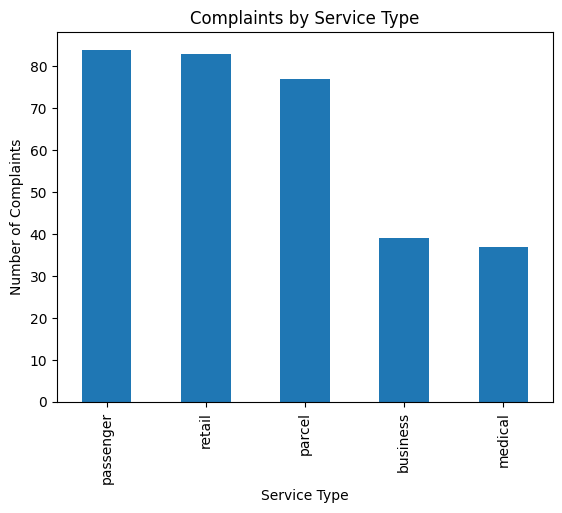

In [11]:
# Visualise complaints by service type

complaints_by_service.plot(kind="bar")

plt.title("Complaints by Service Type")
plt.xlabel("Service Type")
plt.ylabel("Number of Complaints")

plt.show()

service_type
passenger    2.059524
medical      2.054054
business     2.051282
parcel       2.038961
retail       1.927711
Name: severity_score, dtype: float64


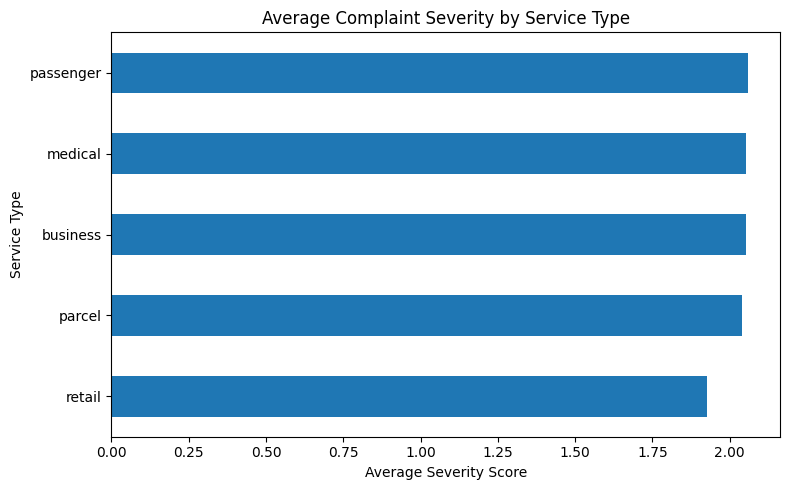

In [12]:
# Analyse average complaint severity

severity_by_service = (
    complaints_analysis_clean
    .groupby("service_type")["severity_score"]
    .mean()
    .sort_values(ascending=False)
)

print(severity_by_service)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

severity_by_service.sort_values().plot(kind="barh")

plt.title("Average Complaint Severity by Service Type")
plt.xlabel("Average Severity Score")
plt.ylabel("Service Type")

plt.tight_layout()
plt.show()

In [13]:
# Identify repeat complaint customers

repeat_customers = (
    complaints_clean
    .groupby("customer_id")
    .size()
    .sort_values(ascending=False)
)

print(repeat_customers.head(10))

customer_id
C0368    4
C0142    3
C0545    3
C0372    3
C0573    3
C0421    3
C0626    3
C0242    3
C0110    3
C0282    3
dtype: int64


In [14]:
# Analyse compensation costs

compensation_by_service = (
    complaints_analysis_clean
    .groupby("service_type")["compensation_amount"]
    .mean()
    .sort_values(ascending=False)
)

print(compensation_by_service)

service_type
business     20.791282
medical      20.000270
passenger    19.732500
parcel       19.008442
retail       17.905301
Name: compensation_amount, dtype: float64


DRIVER PERFORMANCE ANALYSIS

driver_id
D087    6
D146    5
D026    5
D039    5
D004    5
D037    4
D094    4
D154    4
D084    4
D032    4
dtype: int64


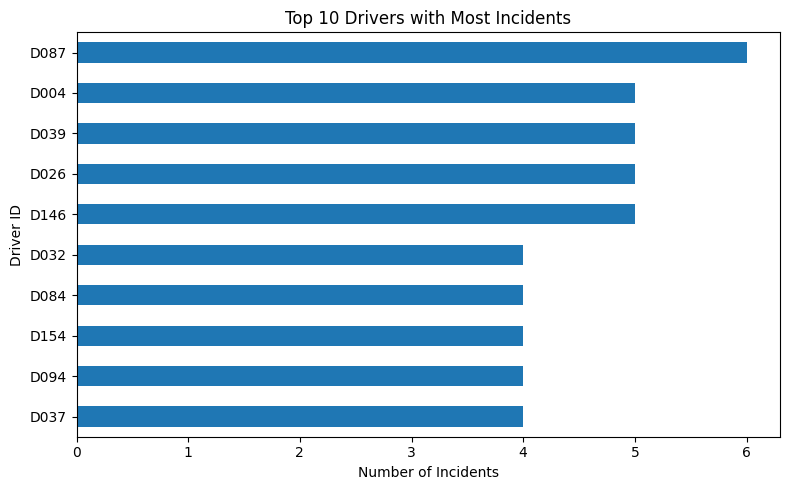

In [30]:
# Count incidents associated with each driver

driver_incidents = (
    incidents_analysis_clean
    .groupby("driver_id")
    .size()
    .sort_values(ascending=False)
)

print(driver_incidents.head(10))

import matplotlib.pyplot as plt

top_drivers = driver_incidents.head(10)

plt.figure(figsize=(8,5))

top_drivers.sort_values().plot(kind="barh")

plt.title("Top 10 Drivers with Most Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Driver ID")

plt.tight_layout()
plt.show()

In [16]:
# Analyse relationship between driver ratings and delay rates

driver_delay_analysis = (
    delivery_analysis_clean
    .groupby("driver_id")
    .agg({
        "is_delayed": "mean",
        "driver_rating": "mean"
    })
)

print(driver_delay_analysis.head())

           is_delayed  driver_rating
driver_id                           
D001         0.333333           3.54
D002         0.428571           3.94
D003         0.500000           5.00
D004         0.555556           4.75
D005         0.750000           4.14


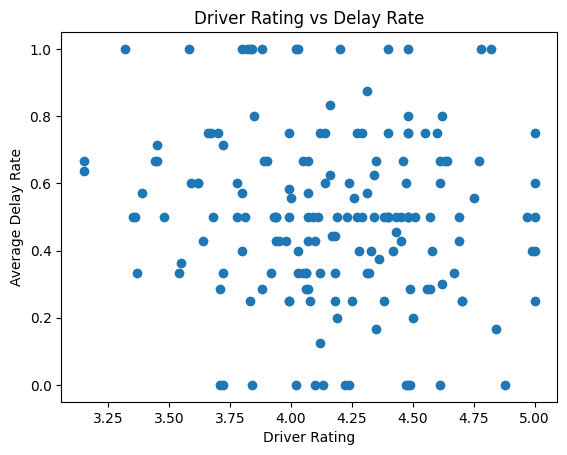

In [17]:
# Visualise relationship between driver rating and delay rate

plt.scatter(
    driver_delay_analysis["driver_rating"],
    driver_delay_analysis["is_delayed"]
)

plt.title("Driver Rating vs Delay Rate")
plt.xlabel("Driver Rating")
plt.ylabel("Average Delay Rate")

plt.show()

VEHICLE RISK ANALYSIS

In [18]:
# Calculate percentage of high-risk vehicles

high_risk_percentage = (
    vehicles_clean["high_risk_vehicle"].mean() * 100
)

print("High-Risk Vehicle Percentage:", round(high_risk_percentage, 2), "%")

High-Risk Vehicle Percentage: 49.17 %


In [19]:
# Analyse battery health across vehicle categories

battery_by_type = (
    vehicles_clean
    .groupby("vehicle_type")["battery_health_pct"]
    .mean()
    .sort_values()
)

print(battery_by_type)

vehicle_type
diesel      70.563158
cargovan    73.383333
hybrid      76.838462
ev          82.124390
Name: battery_health_pct, dtype: float64


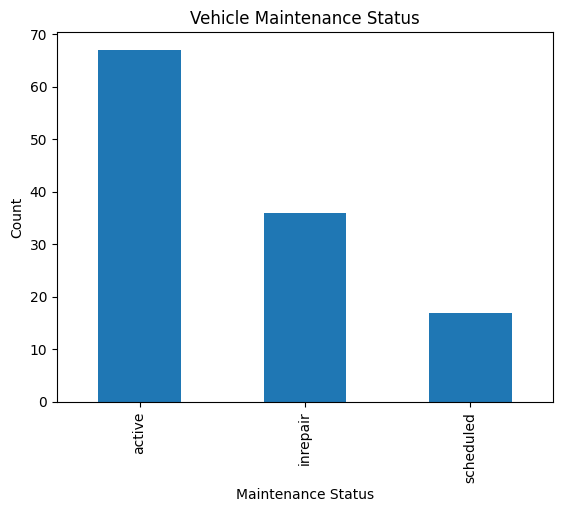

In [20]:
# Visualise maintenance status distribution

maintenance_counts = vehicles_clean["maintenance_status"].value_counts()

maintenance_counts.plot(kind="bar")

plt.title("Vehicle Maintenance Status")
plt.xlabel("Maintenance Status")
plt.ylabel("Count")

plt.show()

high_risk_vehicle
0    0.48000
1    0.52518
Name: is_delayed, dtype: float64


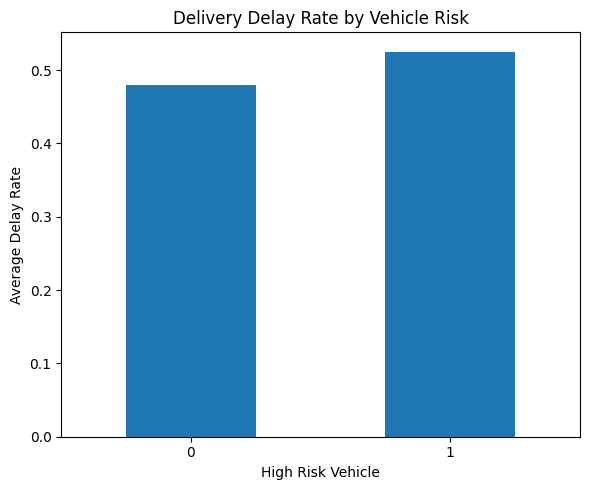

In [31]:
# Merge vehicle risk into delivery analysis

vehicle_delay_analysis = (
    delivery_analysis_clean
    .groupby("high_risk_vehicle")["is_delayed"]
    .mean()
)

print(vehicle_delay_analysis)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

vehicle_delay_analysis.plot(kind="bar")

plt.title("Delivery Delay Rate by Vehicle Risk")
plt.xlabel("High Risk Vehicle")
plt.ylabel("Average Delay Rate")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

HUB EFFICIENCY ANALYSIS

In [22]:
# Count complaints associated with each hub

hub_complaints = (
    delivery_analysis_clean
    .groupby("hub_name")["is_failed"]
    .mean()
    .sort_values(ascending=False)
)

print(hub_complaints)

hub_name
Central Core      0.212963
Midtown Relay     0.211864
Airport Hub       0.157895
North Exchange    0.135593
Riverside Hub     0.129630
West Gate         0.129310
South Link        0.103093
East Dock         0.102804
Name: is_failed, dtype: float64


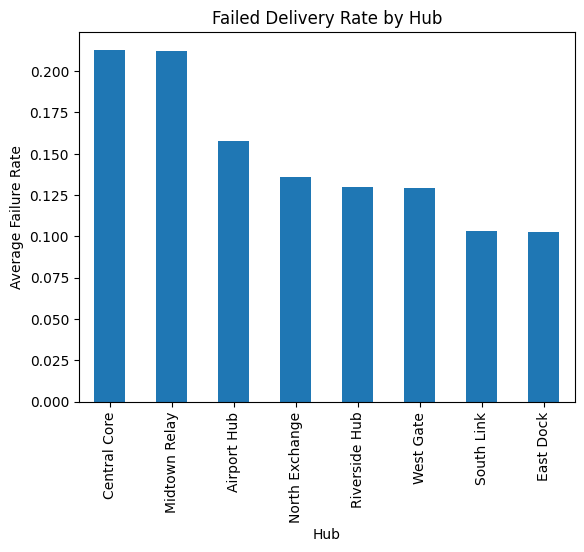

In [23]:
# Visualise failed delivery rate by hub

hub_complaints.plot(kind="bar")

plt.title("Failed Delivery Rate by Hub")
plt.xlabel("Hub")
plt.ylabel("Average Failure Rate")

plt.show()

In [24]:
# Analyse customer ratings across hubs

hub_ratings = (
    delivery_analysis_clean
    .groupby("hub_name")["customer_rating_post_delivery"]
    .mean()
    .sort_values()
)

print(hub_ratings)

hub_name
Central Core      3.669630
North Exchange    3.802542
Airport Hub       3.817789
West Gate         3.887241
Midtown Relay     3.889746
East Dock         3.892617
Riverside Hub     3.894352
South Link        3.935052
Name: customer_rating_post_delivery, dtype: float64


APP EVENT & PLATFORM ANALYSIS

In [25]:
# Analyse app event failures by event category

event_failure_analysis = (
    app_events_clean
    .groupby("event_type")["app_event_failed"]
    .mean()
    .sort_values(ascending=False)
)

print(event_failure_analysis)

event_type
chat_escalated                 0.500000
payment_retry                  0.275362
cancel_attempt                 0.000000
chat_opened                    0.000000
delivery_instruction_update    0.000000
eta_refresh                    0.000000
search_route                   0.000000
track_order                    0.000000
Name: app_event_failed, dtype: float64


In [26]:
# Analyse latency issues by device type

latency_by_device = (
    app_events_clean
    .groupby("device_type")["high_latency_event"]
    .mean()
    .sort_values(ascending=False)
)

print(latency_by_device)

device_type
ios        0.716738
android    0.711111
web        0.706522
Name: high_latency_event, dtype: float64


In [27]:
# Analyse average API latency across zones

latency_by_zone = (
    app_events_clean
    .groupby("zone_context")["api_latency_ms"]
    .mean()
    .sort_values(ascending=False)
)

print(latency_by_zone)

zone_context
airport      606.080460
central      518.580000
ctr          489.348837
north        444.279570
east         434.714286
south        428.473684
west         426.840426
riverside    420.942529
Name: api_latency_ms, dtype: float64


KPI DASHBOARD METRICS

In [28]:
# Calculate important operational KPIs

delay_rate = deliveries_clean["is_delayed"].mean() * 100
failure_rate = deliveries_clean["is_failed"].mean() * 100
average_delivery_time = deliveries_clean["delivery_duration_minutes"].mean()
average_driver_rating = drivers_clean["driver_rating"].mean()
average_customer_rating = deliveries_clean["customer_rating_post_delivery"].mean()
high_risk_vehicle_rate = vehicles_clean["high_risk_vehicle"].mean() * 100
app_failure_rate = app_events_clean["app_event_failed"].mean() * 100

print("Delay Rate:", round(delay_rate, 2), "%")
print("Failure Rate:", round(failure_rate, 2), "%")
print("Average Delivery Duration:", round(average_delivery_time, 2), "minutes")
print("Average Driver Rating:", round(average_driver_rating, 2))
print("Average Customer Rating:", round(average_customer_rating, 2))
print("High-Risk Vehicle Rate:", round(high_risk_vehicle_rate, 2), "%")
print("App Failure Rate:", round(app_failure_rate, 2), "%")

Delay Rate: 50.17 %
Failure Rate: 14.88 %
Average Delivery Duration: 619.03 minutes
Average Driver Rating: 4.17
Average Customer Rating: 3.85
High-Risk Vehicle Rate: 49.17 %
App Failure Rate: 5.94 %


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\legio\\Videos\\northstar_dataset_analysis\\screenshots\\kpi_dashboard.png'

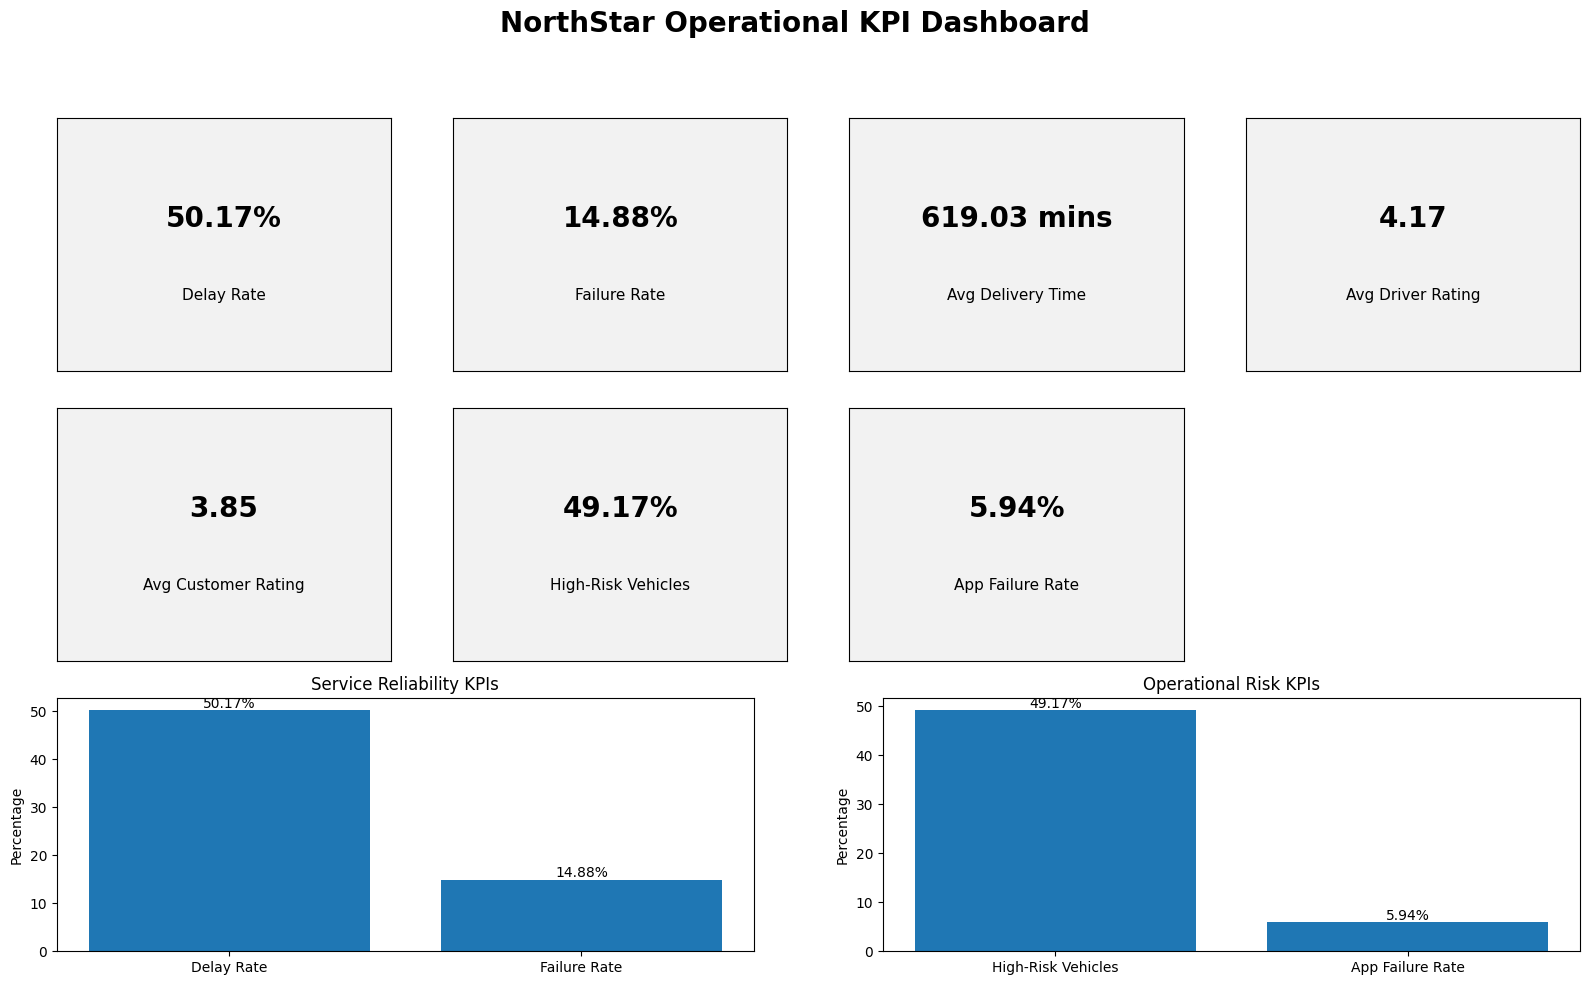

In [29]:
# Create a proper KPI dashboard using matplotlib

fig = plt.figure(figsize=(16, 10))

# Main dashboard title
fig.suptitle(
    "NorthStar Operational KPI Dashboard",
    fontsize=20,
    fontweight="bold"
)

# -------------------------------
# KPI CARD VALUES
# -------------------------------

kpis = [
    ("Delay Rate", f"{delay_rate:.2f}%"),
    ("Failure Rate", f"{failure_rate:.2f}%"),
    ("Avg Delivery Time", f"{average_delivery_time:.2f} mins"),
    ("Avg Driver Rating", f"{average_driver_rating:.2f}"),
    ("Avg Customer Rating", f"{average_customer_rating:.2f}"),
    ("High-Risk Vehicles", f"{high_risk_vehicle_rate:.2f}%"),
    ("App Failure Rate", f"{app_failure_rate:.2f}%")
]

# Create KPI cards
for i, (label, value) in enumerate(kpis):
    ax = fig.add_subplot(3, 4, i + 1)
    ax.text(
        0.5, 0.6,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )
    ax.text(
        0.5, 0.3,
        label,
        ha="center",
        va="center",
        fontsize=11
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f2f2f2")

# -------------------------------
# CHART 1: Delay and Failure Rate
# -------------------------------

ax1 = fig.add_subplot(3, 2, 5)

ax1.bar(
    ["Delay Rate", "Failure Rate"],
    [delay_rate, failure_rate]
)

ax1.set_title("Service Reliability KPIs")
ax1.set_ylabel("Percentage")

for i, value in enumerate([delay_rate, failure_rate]):
    ax1.text(i, value + 0.5, f"{value:.2f}%", ha="center")

# -------------------------------
# CHART 2: Operational Risk KPIs
# -------------------------------

ax2 = fig.add_subplot(3, 2, 6)

ax2.bar(
    ["High-Risk Vehicles", "App Failure Rate"],
    [high_risk_vehicle_rate, app_failure_rate]
)

ax2.set_title("Operational Risk KPIs")
ax2.set_ylabel("Percentage")

for i, value in enumerate([high_risk_vehicle_rate, app_failure_rate]):
    ax2.text(i, value + 0.5, f"{value:.2f}%", ha="center")

# Improve spacing
plt.tight_layout(rect=[0, 0, 1, 0.93])

# Save dashboard image
plt.savefig("../screenshots/kpi_dashboard.png", dpi=300, bbox_inches="tight")

# Show dashboard
plt.show()